# Laptop Price Prediction - Jupyter Notebook

This Jupyter Notebook contains all the Exploratory Data Analysis (EDA) and an initial look at the functions needed to construct the pipeline present in the `.py` files. Therefore, the final model is not trained here, but in the `main.py` file.

In [432]:
# dataset = https://www.kaggle.com/datasets/adityamishraml/laptops/data
import pandas as pd
import numpy as np
import requests

In [488]:
raw_data = pd.read_csv("dataset/Laptops.csv")

In [9]:
raw_data.head()

,indx,Company,TypeName,Inches,touchscreen,ipspanel,retinadisplay,resolution_width,resolution_height,cpu_brand,...,Memory,hdd,ssd,flashstorage,hybrid,gpu_brand,gpu_name,OpSys,Weight_kg,Price
0,1,Toshiba,Ultrabook,13.3,0,0,0,1920,1080,Intel,...,256GB SSD,0,256,0,0,Intel,HD Graphics 520,windows,1.20,72621
1,2,Apple,Ultrabook,13.3,0,1,1,2560,1600,Intel,...,128GB SSD,0,128,0,0,Intel,Iris Plus Graphics 640,macos,1.37,71379
2,3,HP,Notebook,17.3,0,0,0,1920,1080,Intel,...,128GB SSD + 1TB HDD,1024,128,0,0,Nvidia,GeForce 930MX,windows,2.50,52055
3,4,Dell,Notebook,15.6,0,0,0,1920,1080,Intel,...,1TB HDD,1024,0,0,0,Intel,HD Graphics 620,windows,2.18,35005
4,5,HP,Notebook,15.6,0,0,0,1920,1080,AMD,...,256GB SSD,0,256,0,0,AMD,Radeon R4 Graphics,windows,1.86,21232


In [11]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   indx               1272 non-null   int64  
 1   Company            1272 non-null   object 
 2   TypeName           1272 non-null   object 
 3   Inches             1272 non-null   float64
 4   touchscreen        1272 non-null   int64  
 5   ipspanel           1272 non-null   int64  
 6   retinadisplay      1272 non-null   int64  
 7   resolution_width   1272 non-null   int64  
 8   resolution_height  1272 non-null   int64  
 9   cpu_brand          1272 non-null   object 
 10  cpu_name           1272 non-null   object 
 11  cpu_speed          1272 non-null   float64
 12  Ram                1272 non-null   int64  
 13  Memory             1272 non-null   object 
 14  hdd                1272 non-null   int64  
 15  ssd                1272 non-null   int64  
 16  flashstorage       1272 

In [23]:
raw_data.isna().sum()

indx                  0
Company               0
TypeName              0
Inches                0
touchscreen           0
ipspanel              0
retinadisplay         0
resolution_width      0
resolution_height     0
cpu_brand             0
cpu_name              0
cpu_speed             0
Ram                   0
Memory                0
hdd                   0
ssd                   0
flashstorage          0
hybrid                0
gpu_brand             0
gpu_name              0
OpSys                63
Weight_kg             0
Price                 0
dtype: int64

In [25]:
raw_data.describe()

,indx,Inches,touchscreen,ipspanel,retinadisplay,resolution_width,resolution_height,cpu_speed,Ram,hdd,ssd,flashstorage,hybrid,Weight_kg,Price
count,1272.00000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000
mean,636.50000,15.130818,0.145440,0.282233,0.013365,1894.199686,1070.531447,2.298192,8.463050,423.132075,182.534591,4.591195,9.254717,2.076211,59902.143082
std,367.33908,1.954436,0.352683,0.450263,0.114876,494.389426,284.512222,0.507680,5.566582,527.514262,185.636660,30.578213,95.876648,0.809869,37297.683852
min,1.00000,10.100000,0.000000,0.000000,0.000000,1366.000000,768.000000,0.900000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9271.000000
25%,318.75000,14.000000,0.000000,0.000000,0.000000,1600.000000,900.000000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.500000,31915.000000
50%,636.50000,15.600000,0.000000,0.000000,0.000000,1920.000000,1080.000000,2.500000,8.000000,0.000000,256.000000,0.000000,0.000000,2.040000,52108.000000
75%,954.25000,15.600000,0.000000,1.000000,0.000000,1920.000000,1080.000000,2.700000,8.000000,1024.000000,256.000000,0.000000,0.000000,2.320000,79244.500000
max,1272.00000,35.600000,1.000000,1.000000,1.000000,3840.000000,2160.000000,3.600000,64.000000,2048.000000,1024.000000,512.000000,1024.000000,11.100000,324955.000000


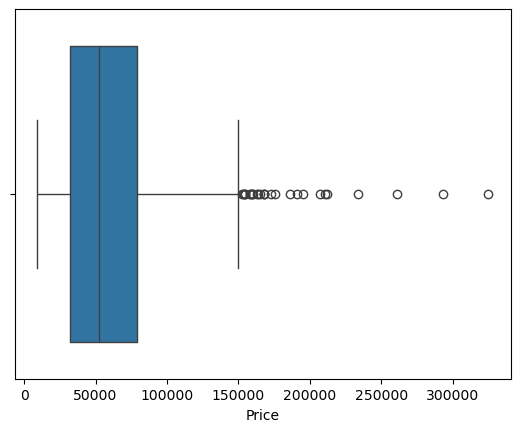

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=raw_data['Price'])
plt.show()

In [61]:
100*raw_data[raw_data['Price']>150000].size/raw_data.size

2.20125786163522

In [35]:
raw_data[raw_data['OpSys'].isna()==True]

,indx,Company,TypeName,Inches,touchscreen,ipspanel,retinadisplay,resolution_width,resolution_height,cpu_brand,...,Memory,hdd,ssd,flashstorage,hybrid,gpu_brand,gpu_name,OpSys,Weight_kg,Price
27,28,Lenovo,Gaming,15.6,0,1,0,1920,1080,Intel,...,256GB SSD,0,256,0,0,Nvidia,GeForce GTX 1050,NaN,2.40,41505
43,44,Xiaomi,Ultrabook,13.3,0,1,0,1920,1080,Intel,...,256GB SSD,0,256,0,0,Nvidia,GeForce MX150,NaN,1.30,53275
55,56,Lenovo,Notebook,15.6,0,0,0,1920,1080,Intel,...,128GB SSD,0,128,0,0,Intel,HD Graphics 520,NaN,1.85,21498
66,67,Lenovo,Notebook,14.0,0,1,0,1920,1080,Intel,...,256GB SSD,0,256,0,0,Intel,HD Graphics 620,NaN,1.70,31915
69,70,HP,Notebook,15.6,0,0,0,1920,1080,Intel,...,500GB HDD,500,0,0,0,Intel,HD Graphics 520,NaN,1.86,18381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,1193,Lenovo,Notebook,15.6,0,1,0,1920,1080,Intel,...,256GB SSD,0,256,0,0,Intel,HD Graphics 620,NaN,2.30,30529
1195,1196,Lenovo,Notebook,17.3,0,0,0,1600,900,Intel,...,1TB HDD,1024,0,0,0,Intel,HD Graphics 620,NaN,2.80,28718
1224,1225,HP,Notebook,15.6,0,0,0,1366,768,Intel,...,500GB HDD,500,0,0,0,Intel,HD Graphics 520,NaN,2.10,25414
1259,1260,Lenovo,Notebook,15.6,0,0,0,1366,768,Intel,...,500GB HDD,500,0,0,0,Intel,HD Graphics 520,NaN,2.10,21205


In [43]:
raw_data.columns

Index(['indx', 'Company', 'TypeName', 'Inches', 'touchscreen', 'ipspanel',
       'retinadisplay', 'resolution_width', 'resolution_height', 'cpu_brand',
       'cpu_name', 'cpu_speed', 'Ram', 'Memory', 'hdd', 'ssd', 'flashstorage',
       'hybrid', 'gpu_brand', 'gpu_name', 'OpSys', 'Weight_kg', 'Price'],
      dtype='object')

In [47]:
raw_data['Company'].value_counts()

Company
Lenovo       290
Dell         286
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
LG             3
Huawei         2
Fujitsu        2
Name: count, dtype: int64

In [49]:
raw_data['TypeName'].value_counts()

TypeName
Notebook              710
Gaming                203
Ultrabook             191
2 in 1 Convertible    116
Workstation            28
Netbook                24
Name: count, dtype: int64

In [51]:
raw_data['Inches'].value_counts()

Inches
15.6    640
14.0    192
17.3    162
13.3    161
12.5     38
11.6     31
13.9      6
12.0      6
12.3      5
13.5      5
15.4      4
15.0      4
35.6      3
10.1      3
13.0      2
24.0      2
18.4      1
33.5      1
25.6      1
27.3      1
31.6      1
17.0      1
11.3      1
14.1      1
Name: count, dtype: int64

In [53]:
raw_data['touchscreen'].value_counts()

touchscreen
0    1087
1     185
Name: count, dtype: int64

In [55]:
raw_data['ipspanel'].value_counts()

ipspanel
0    913
1    359
Name: count, dtype: int64

In [57]:
raw_data['retinadisplay'].value_counts()

retinadisplay
0    1255
1      17
Name: count, dtype: int64

In [61]:
raw_data['Memory'].value_counts()

Memory
256GB SSD                        400
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
512GB SSD +  1TB HDD              14
64GB Flash Storage                14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
128GB Flash Storage                4
180GB SSD                          4
512GB SSD +  2TB HDD               3
16GB SSD                           3
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
256GB SSD +  256GB SSD             2
128GB SSD +  2TB HDD               2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [67]:
raw_data['gpu_brand'].value_counts()

gpu_brand
Intel     703
Nvidia    392
AMD       176
ARM         1
Name: count, dtype: int64

In [69]:
raw_data['gpu_name'].value_counts()

gpu_name
HD Graphics 620      271
HD Graphics 520      181
UHD Graphics 620      66
GeForce GTX 1050      64
GeForce GTX 1060      48
                    ... 
Radeon R5 520          1
HD Graphics 540        1
GeForce GTX 1070M      1
Radeon R7 M465         1
FirePro W6150M         1
Name: count, Length: 110, dtype: int64

In [462]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(raw_data, test_size=0.2, random_state=42)

data=train_set

In [464]:
def cut_price_outliers(df):
    if 'Price' not in df.columns:
        print(" 'Price' Column not include on the dataset.")
        return df
    new_df = df[df['Price'] < 150000].copy()
    return new_df

data = cut_price_outliers(data)

In [466]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class DataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, clean_data=True, op_sys_col='OpSys'):
        self.clean_data = clean_data
        self.op_sys_col = op_sys_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not self.clean_data:
            return X
        X_copy = X.copy()

        if self.op_sys_col in X_copy.columns:
            X_copy[self.op_sys_col] = X_copy[self.op_sys_col].fillna("No Operation System")

        if 'Memory' in X_copy.columns:
            X_copy = X_copy.drop(columns=['Memory'])

        if X_copy.isna().sum().sum() > 0:
            print("Warning: Dropping remaining rows with NaNs")
            X_copy = X_copy.dropna()

        return X_copy

In [468]:
class GPUTierExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, gpu_col='gpu_name'):
        self.gpu_col = gpu_col

    def fit(self, X, y=None):
        return self

    def _categorize_gpu(self, gpu_string):
        gpu_string = str(gpu_string).upper()
        if 'HD GRAPHICS' in gpu_string or 'UHD' in gpu_string or 'IRIS' in gpu_string:
            return 'Integrated_Graphics'
        elif 'GTX' in gpu_string or 'RTX' in gpu_string:
            return 'Nvidia_Premium'
        elif 'QUADRO' in gpu_string or 'FIREPRO' in gpu_string:
            return 'Workstation_GPU'
        elif 'RADEON' in gpu_string or 'RX ' in gpu_string:
            return 'AMD_Radeon'
        elif 'GEFORCE' in gpu_string or 'NVIDIA' in gpu_string:
            return 'Nvidia_Standard'
        else:
            return 'Other'

    def transform(self, X):
        X_copy = X.copy()
        
        if self.gpu_col in X_copy.columns:
            X_copy['gpu_tier'] = X_copy[self.gpu_col].apply(self._categorize_gpu)
            X_copy = X_copy.drop(columns=[self.gpu_col])
            
        return X_copy

In [470]:
def price_to_usd(df):
    if not isinstance(df, pd.DataFrame):
        print("Error: Please pass a full DataFrame, not just a column.")
        return df

    if 'Price' not in df.columns:
        return df

    new_df = df.copy()
    
    url = "https://api.exchangerate-api.com/v4/latest/USD"
    fallback = 83.12
    try:
        response = requests.get(url, timeout=5)
        rate = response.json()['rates']['INR']
    except Exception as e:
        print(f"Using fallback rate due to: {e}")
        rate = fallback
    new_df['Price'] = (new_df['Price'] / rate).round(2)
    
    return new_df

def clean_target(dataset):
    if 'Price' not in dataset.columns:
        print(" 'Price' Column not include on the dataset.")
        return dataset
    return price_to_usd(dataset)['Price']

target=clean_target(data)
target=np.log(target)

In [472]:
from sklearn.pipeline import Pipeline

base_pipeline = Pipeline([
    ('cleaner', DataCleaner()),
    ('gpu_engineer', GPUTierExtractor(gpu_col='gpu_name'))
])

temp_data = base_pipeline.fit_transform(data)

num_attribs = temp_data.select_dtypes(include=['number']).drop(columns=['Price'], errors='ignore').columns.tolist()
cat_attribs = temp_data.select_dtypes(include=['object', 'category']).columns.tolist()

col_transformer = ColumnTransformer([
    ("num", StandardScaler(), num_attribs),
    ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_attribs)
])

full_pipeline = Pipeline([
    ('base_prep', base_pipeline),
    ('features', col_transformer)
])

dataset_prepared = full_pipeline.fit_transform(data)

In [474]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(dataset_prepared, target)

LinearRegression()

In [396]:
from sklearn.metrics import mean_squared_error
lin_predictions = lin_reg.predict(dataset_prepared)
lin_mse=mean_squared_error(target, lin_predictions)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

0.19515601834031554

In [398]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(dataset_prepared, target)
tree_predictions = tree_reg.predict(dataset_prepared)
tree_mse=mean_squared_error(target, tree_predictions)
tree_rmse=np.sqrt(tree_mse)
tree_rmse

0.0

In [400]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, dataset_prepared, target, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Std:", scores.std())

display_scores(tree_rmse_scores)

Scores: [0.30198818 0.24954643 0.2873396  0.29797275 0.29140642 0.31932914
 0.26975561 0.32330549 0.37427178 0.30612212]
Mean: 0.3021037531297548
Std: 0.03182572040118566


In [448]:
from sklearn.ensemble import RandomForestRegressor

tree_reg = RandomForestRegressor()
tree_reg.fit(dataset_prepared, target)
tree_predictions = tree_reg.predict(dataset_prepared)
tree_mse=mean_squared_error(target, tree_predictions)
tree_rmse=np.sqrt(tree_mse)
tree_rmse

0.07939726836820687

In [403]:
scores = cross_val_score(tree_reg, dataset_prepared, target, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Std:", scores.std())

display_scores(tree_rmse_scores)

Scores: [0.18801115 0.18635673 0.2351809  0.22981857 0.19112893 0.21355385
 0.20437094 0.24939391 0.25131371 0.22808629]
Mean: 0.2177214986516597
Std: 0.02336536373495789


In [482]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators':[3,10,30], 'max_features':[2,4,6,8]},
    {'bootstrap':[False], 'n_estimators':[3,10], 'max_features':[2,3,4]}
]

new_forest_reg= RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(new_forest_reg, param_grid,cv=5, scoring='neg_mean_squared_error', return_train_score=True)

grid_search.fit(dataset_prepared,target)

print('Best Params:', grid_search.best_params_)

Best Params: {'max_features': 4, 'n_estimators': 30}


In [483]:
final_model = grid_search.best_estimator_

test_set = cut_price_outliers(test_set)

X_test = test_set.drop("Price", axis=1)
Y_test= np.log(clean_target(test_set))

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(Y_test, final_predictions)
final_rmse=np.sqrt(final_mse)

In [454]:
final_rmse

0.2022317721445084

In [408]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - Y_test)**2
np.sqrt(stats.t.interval(confidence,len(squared_errors)-1, loc=squared_errors.mean(), scale=stats.sem(squared_errors)))

array([0.17828964, 0.21573876])

<Axes: >

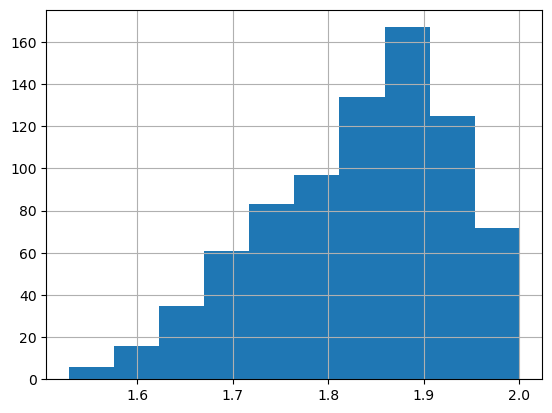

In [409]:
np.log(target).hist()

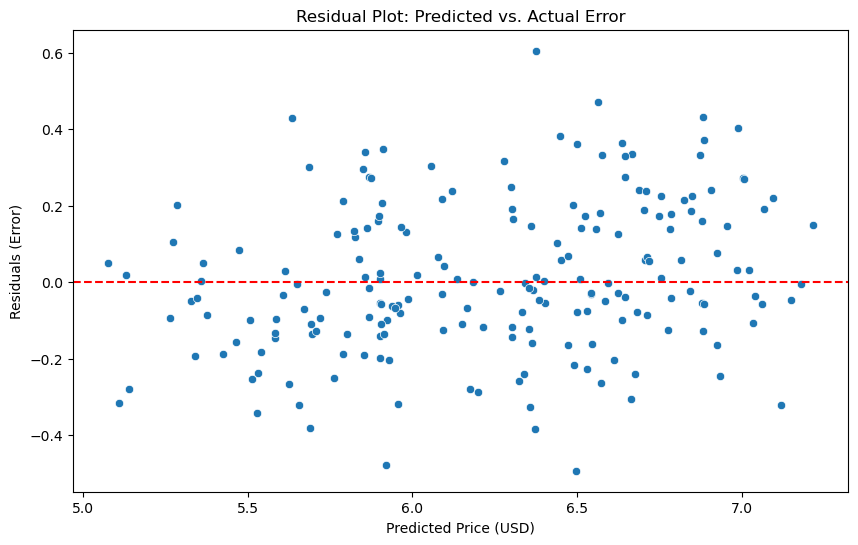

In [410]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = Y_test - final_predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=final_predictions, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot: Predicted vs. Actual Error')
plt.show()

In [486]:
import numpy as np
from sklearn.metrics import mean_squared_error

predictions_usd = np.exp(final_predictions)
Y_test_usd = np.exp(Y_test)

final_mse_usd = mean_squared_error(Y_test_usd, predictions_usd)
final_rmse_usd = np.sqrt(final_mse_usd)

print(f"Final RMSE in Dollars: ${final_rmse_usd:.2f}")

Final RMSE in Dollars: $164.85


In [458]:
from scipy import stats
import numpy as np
predictions_usd = np.exp(final_predictions)
Y_test_usd = np.exp(Y_test)
squared_errors_usd = (predictions_usd - Y_test_usd) ** 2
confidence = 0.95
mean_sq_err_usd = squared_errors_usd.mean()
standard_error_usd = stats.sem(squared_errors_usd)

interval_usd = np.sqrt(stats.t.interval(
    confidence, 
    len(squared_errors_usd) - 1, 
    loc=mean_sq_err_usd, 
    scale=standard_error_usd
))

print(f"95% Confidence Interval in USD: ${interval_usd[0]:.2f} to ${interval_usd[1]:.2f}")

95% Confidence Interval in USD: $139.11 to $186.88


In [428]:
np.exp(Y_test).describe()

count     199.000000
mean      610.376683
std       350.306444
min       120.900000
25%       346.455000
50%       514.230000
75%       855.830000
max      1619.050000
Name: Price, dtype: float64